# TIME SERIES AND ECONOMETRICS


Prepared by: Joannah Mawutsa

Registration Number: R2424533

BSc Honours in Data Science and Systems | University of Zimbabwe




# **Executive Summary**

This project explores some of the common challenges faced in financial econometrics and time series analysis, especially in areas such as derivative pricing, risk management, and financial forecasting. The study focuses on four key problems: multicollinearity, skewness, sensitivity to outliers, and overfitting. These issues can reduce the accuracy and reliability of financial models if they are not properly identified and addressed.

For each challenge, the project explains the concept using formulas and simple explanations, followed by practical demonstrations using [simulated](https://) financial data. Graphs and visualizations are also included to help show how these problems appear in real datasets. In addition, different diagnostic methods are discussed together with the possible effects these challenges can have on financial analysis and decision-making.

The analysis shows that multicollinearity can make regression results unstable, skewness can affect the distribution of returns, outliers can distort statistical results, and overfitting can lead to poor predictions when new data is introduced. The project also outlines several methods that can be used to reduce or solve these problems in practice.
Overall, this handbook emphasizes the importance of using proper econometric techniques when working with financial data. Correctly identifying and handling these challenges helps improve forecasting accuracy, supports better risk management, and leads to more informed financial decisions.

In [95]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, jarque_bera
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
print("Libraries imported successfully.")

# Download AAPL data from 2018-01-01 to 2025-12-31
ticker = "AAPL"
start_date = "2018-01-01"
end_date = "2025-12-31"

# Download with auto_adjust=False to get all columns including Adj Close
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, progress=False)

print("Available columns:")
print(df.columns.tolist())
print(f"\nData shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()

Libraries imported successfully.
Available columns:
[('Adj Close', 'AAPL'), ('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

Data shape: (2010, 6)
Date range: 2018-01-02 00:00:00 to 2025-12-30 00:00:00


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2018-01-02,40.304161,43.064999,43.075001,42.314999,42.540001,102223600
2018-01-03,40.297157,43.057499,43.637501,42.990002,43.132500,118071600
2018-01-04,40.484333,43.257500,43.367500,43.020000,43.134998,89738400
2018-01-05,40.945255,43.750000,43.842499,43.262501,43.360001,94640000
2018-01-08,40.793182,43.587502,43.902500,43.482498,43.587502,82271200


In [96]:

print("TAIL - Last 5 rows of the dataset:")

df.tail()

TAIL - Last 5 rows of the dataset:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2025-12-23,272.105377,272.359985,272.500000,269.559998,270.839996,29642000
2025-12-24,273.554016,273.809998,275.429993,272.200012,272.339996,17910600
2025-12-26,273.144409,273.399994,275.369995,272.859985,274.160004,21521800
2025-12-29,273.504089,273.760010,274.359985,272.350006,272.690002,23715200
2025-12-30,272.824707,273.079987,274.079987,272.279999,272.809998,22139600


In [97]:
# Clean and prepare data
if 'Adj Close' in df.columns:
    price_col = 'Adj Close'
    print("Using 'Adj Close' column")
elif 'Close' in df.columns:
    price_col = 'Close'
    print("Using 'Close' column")

# Create clean dataframe with prices and returns
df_clean = pd.DataFrame()
df_clean['Price'] = df[price_col]
df_clean['Return'] = df_clean['Price'].pct_change() * 100  # percentage returns
df_clean = df_clean.dropna()

print(f"\nFinal data shape: {df_clean.shape}")
print(f"Date range: {df_clean.index[0].date()} to {df_clean.index[-1].date()}")
print(f"Total trading days: {len(df_clean)}")
print(f"\nFirst 5 rows:")
df_clean.head()

Using 'Adj Close' column

Final data shape: (2009, 2)
Date range: 2018-01-03 to 2025-12-30
Total trading days: 2009

First 5 rows:


,Price,Return
Date,,
2018-01-03,40.297157,-0.017377
2018-01-04,40.484333,0.464489
2018-01-05,40.945255,1.138520
2018-01-08,40.793182,-0.371405
2018-01-09,40.788509,-0.011455


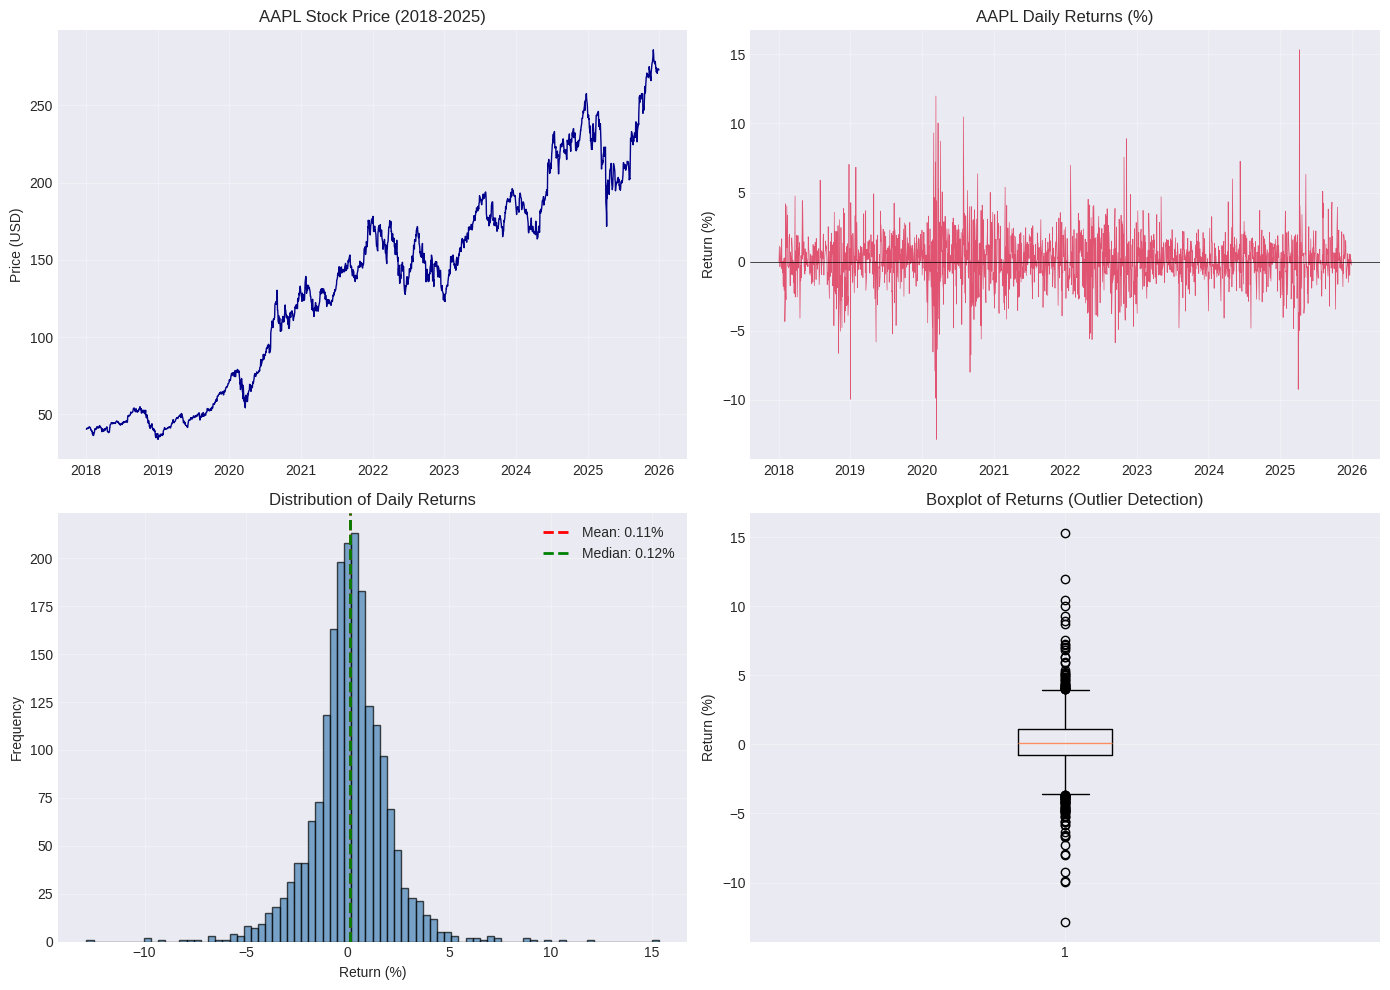

In [98]:
*fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price series
axes[0, 0].plot(df_clean.index, df_clean['Price'], color='darkblue', linewidth=1)
axes[0, 0].set_title('AAPL Stock Price (2018-2025)', fontsize=12)
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].grid(True, alpha=0.3)

# Returns series
axes[0, 1].plot(df_clean.index, df_clean['Return'], color='crimson', alpha=0.7, linewidth=0.5)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].set_title('AAPL Daily Returns (%)', fontsize=12)
axes[0, 1].set_ylabel('Return (%)')
axes[0, 1].grid(True, alpha=0.3)

# Returns distribution
axes[1, 0].hist(df_clean['Return'], bins=80, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=df_clean['Return'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {df_clean["Return"].mean():.2f}%')
axes[1, 0].axvline(x=df_clean['Return'].median(), color='green', linestyle='--', linewidth=2,
                   label=f'Median: {df_clean["Return"].median():.2f}%')
axes[1, 0].set_title('Distribution of Daily Returns', fontsize=12)
axes[1, 0].set_xlabel('Return (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Boxplot for outlier detection
axes[1, 1].boxplot(df_clean['Return'], vert=True)
axes[1, 1].set_title('Boxplot of Returns (Outlier Detection)', fontsize=12)
axes[1, 1].set_ylabel('Return (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# CHALLENGE 1: SKEWNESS


DEFINITION:

Skewness measures the asymmetry of a return distribution:
S = E[(X-μ)³/σ³] = (1/n)Σ(rᵢ - r̄)³ / [(1/n)Σ(rᵢ - r̄)²]^(3/2)

DESCRIPTION:

Positive skewness (right tail heavier) → More frequent small losses
but occasional large gains.

NUMERICAL EXAMPLE:

Skewness of AAPL daily returns: 0.154652
This indicates positive skewness.

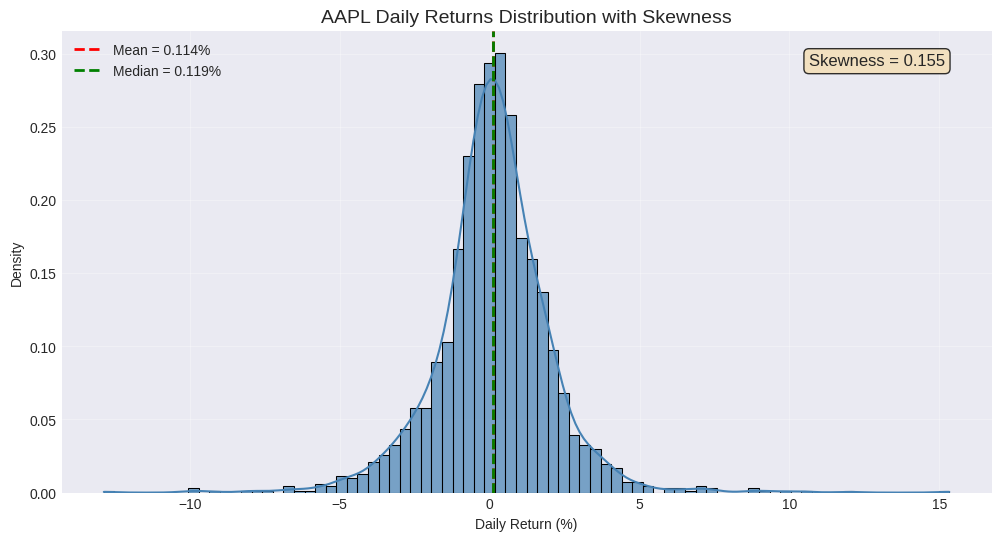

In [99]:
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram with KDE
sns.histplot(returns, bins=80, kde=True, stat='density', ax=ax, color='steelblue', alpha=0.7)
ax.axvline(x=returns.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {returns.mean():.3f}%')
ax.axvline(x=returns.median(), color='green', linestyle='--', linewidth=2,
           label=f'Median = {returns.median():.3f}%')

# Add skewness annotation
ax.text(0.95, 0.95, f'Skewness = {skewness_value:.3f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_title(f'AAPL Daily Returns Distribution with Skewness', fontsize=14)
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


# DIAGNOSIS
How to recognize skewness:

1. Jarque-Bera Normality Test:

   Test statistic: 3466.01

   P-value: 0.000000

   ✓ REJECT normality → Significant skewness present


2. Rule of Thumb Thresholds:

   |Skewness| = 0.155

   → Approximately symmetric


3. Compare Mean vs Median:

   Mean = 0.1140%

   Median = 0.1187%
   
   Difference = -0.0047%


DAMAGE
If skewness is ignored in volatility modeling:

-VaR (Value at Risk) underestimates downside tail risk

-Black-Scholes option pricing becomes inaccurate for OTM options

-Mean-variance optimization fails (ignores third moment preferences)

-Hedging strategies become suboptimal during market stress

-Expected shortfall calculations are biased


DIRECTIONS

Suggested models and methods to address skewness:

-EGARCH (Exponential GARCH) - captures asymmetric volatility response

-GJR-GARCH (Glosten-Jagannathan-Runkle) - leverage effects

-Cornish-Fisher VaR - adjusts for skewness and kurtosis

-Johnson SU transformation - normalizes skewed data

-Nonparametric methods - historical simulation with longer windows

-Heavy-tailed distributions (Student-t, GED) for error terms


# CHALLENGE 2: SENSITIVITY TO OUTLIERS


**DEFINITION **

An outlier is an observation that lies an abnormal distance from other values:
MAD = median(|rᵢ - median(r)|)
Outlier if |rᵢ - median(r)| > 3 × MAD

**DESCRIPTION**

Extreme return events (COVID crash, earnings surprises, macro news)
disproportionately influence model estimates and can mask true
underlying volatility dynamics.

**NUMERICAL EXAMPLE**

Total observations: 2009

Outliers detected (3σ rule): 29 (1.44%)

Outliers detected (3×MAD rule): 225 (11.20%)

**Top 5 most extreme negative returns (largest losses):**

  2020-03-16: -12.86%

  2019-01-03: -9.96%

  2020-03-12: -9.88%

  2025-04-03: -9.25%

  2020-09-03: -8.01%

**Top 5 most extreme positive returns (largest gains):**

  2025-04-09: 15.33%

  2020-03-13: 11.98%

  2020-07-31: 10.47%

  2020-03-24: 10.03%

  2020-03-02: 9.31%


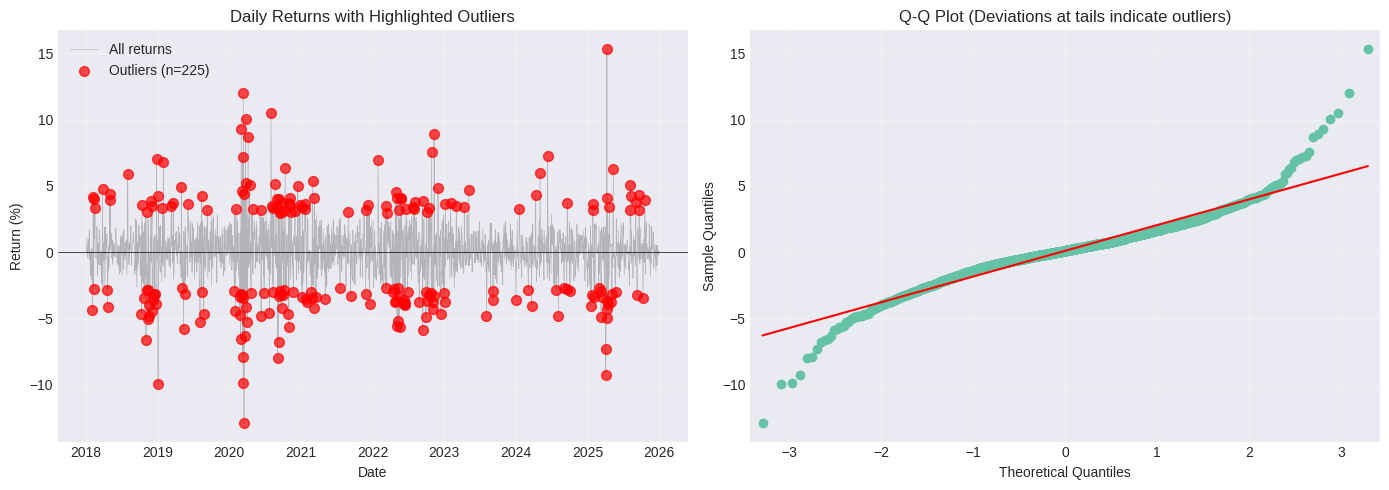

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series with outliers highlighted
axes[0].plot(df_clean.index, returns, color='gray', alpha=0.5, linewidth=0.5, label='All returns')
axes[0].scatter(outliers_mad.index, outliers_mad, color='red', s=50,
                label=f'Outliers (n={len(outliers_mad)})', zorder=3, alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('Daily Returns with Highlighted Outliers', fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot
sm.qqplot(returns, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot (Deviations at tails indicate outliers)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

DIAGNOSIS
How to recognize outliers:

1. Z-score method: |z| > 3 indicates potential outlier
   Observations with |z| > 3: 29

2. Interquartile Range (IQR) method:
   Q1 = -0.7925%, Q3 = 1.1071%, IQR = 1.8996
   Outliers by IQR rule: 107 (5.33%)

3. Visual inspection methods:
   • Boxplot: Points beyond whiskers
   • Histogram: Isolated bars far from main distribution
   • Q-Q plot: Deviations from straight line at tails
   • Time series plot: Spikes that stand out dramatically


# 【IMPACT ON MODEL PARAMETERS】
AR(1) Model: Return_t = α + β × Return_{t-1} + ε_t

**With outliers included:**

  β coefficient: -0.071095

  Standard error: 0.022271

  t-statistic: -3.19

  R-squared: 0.0051


**Without outliers (MAD-based removal):**

  β coefficient: 0.009062

  Standard error: 0.016450

  t-statistic: 0.55

  R-squared: 0.0002


Change in β: 8.02% relative difference


# CHALLENGE 3: OVERFITTING


DEFINITION

Overfitting occurs when a model learns random noise instead of true signal.
In-sample fit (high R²) but poor out-of-sample performance indicates overfitting.

DESCRIPTION

Adding too many lags, exogenous variables, or complex GARCH extensions
can capture random patterns that don't replicate out-of-sample, harming
forecasting performance and derivative pricing.

NUMERICAL EXAMPLE

Simulated 2000 observations from a true GARCH(1,1) process
True parameters: ω=0.05, α=0.1, β=0.85
We will compare a simple model (1 lag) vs overfitted model (20 lags)

In [101]:
# Create lag features
df_sim = pd.DataFrame({'Return': sim_returns})
for lag in range(1, 21):
    df_sim[f'Lag_{lag}'] = df_sim['Return'].shift(lag)
df_sim = df_sim.dropna()

# Train-test split (70-30)
train_size = int(0.7 * len(df_sim))
train = df_sim.iloc[:train_size]
test = df_sim.iloc[train_size:]

X_train = train.drop('Return', axis=1)
y_train = train['Return']
X_test = test.drop('Return', axis=1)
y_test = test['Return']

print(f"\nData split:")
print(f"Training set: {len(train)} observations (70%)")
print(f"Test set: {len(test)} observations (30%)")
print(f"Features created: 20 lags of returns")
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")


Data split:
Training set: 1386 observations (70%)
Test set: 594 observations (30%)
Features created: 20 lags of returns
Training features shape: (1386, 20)
Test features shape: (594, 20)


In [102]:
# Simple model: only Lag_1
model_simple = sm.OLS(y_train, sm.add_constant(X_train[['Lag_1']])).fit()

# Overfitted model: all 20 lags
model_overfit = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# Predictions
y_pred_simple = model_simple.predict(sm.add_constant(X_test[['Lag_1']]))
y_pred_overfit = model_overfit.predict(sm.add_constant(X_test))

# Calculate MSE
mse_simple = mean_squared_error(y_test, y_pred_simple)
mse_overfit = mean_squared_error(y_test, y_pred_overfit)

print("\n【MODEL COMPARISON】")
print("\nSimple Model (1 lag):")
print(f"  In-sample R²: {model_simple.rsquared:.6f}")
print(f"  Out-of-sample MSE: {mse_simple:.6f}")
print(f"  Number of parameters: {len(model_simple.params)}")
print(f"  Adjusted R²: {model_simple.rsquared_adj:.6f}")

print("\nOverfitted Model (20 lags):")
print(f"  In-sample R²: {model_overfit.rsquared:.6f}")
print(f"  Out-of-sample MSE: {mse_overfit:.6f}")
print(f"  Number of parameters: {len(model_overfit.params)}")
print(f"  Adjusted R²: {model_overfit.rsquared_adj:.6f}")

print(f"\n【OVERFITTING DIAGNOSED】")
print(f"Out-of-sample error penalty: {(mse_overfit/mse_simple - 1)*100:.1f}% HIGHER")
print(f"Despite {(model_overfit.rsquared/model_simple.rsquared - 1)*100:.1f}% HIGHER in-sample R²")


【MODEL COMPARISON】

Simple Model (1 lag):
  In-sample R²: 0.000067
  Out-of-sample MSE: 0.898983
  Number of parameters: 2
  Adjusted R²: -0.000655

Overfitted Model (20 lags):
  In-sample R²: 0.014079
  Out-of-sample MSE: 0.906352
  Number of parameters: 21
  Adjusted R²: -0.000367

【OVERFITTING DIAGNOSED】
Out-of-sample error penalty: 0.8% HIGHER
Despite 20855.3% HIGHER in-sample R²


# DAMAGE
If overfitting is ignored:

-Poor out-of-sample forecasting accuracy models don't generalize

-Unreliable risk estimates (VaR, ES) for future periods

-Suboptimal trading strategies based on spurious patterns

-Difficulty in model interpretation capturing noise, not signaI

-Increased risk of capital losses from misguided decisions

# DIRECTIONS
Suggested methods to address overfitting:

-Cross-validation: Evaluate model performance on unseen data

- Regularization (Lasso, Ridge): Penalize complex models

-Feature selection: Use only relevant predictors e.g., AIC, BIC

-Simpler models: Prefer parsimonious models when possible

-Increase data size: More data helps models generalize better

-Ensemble methods: Combine multiple models to reduce variance

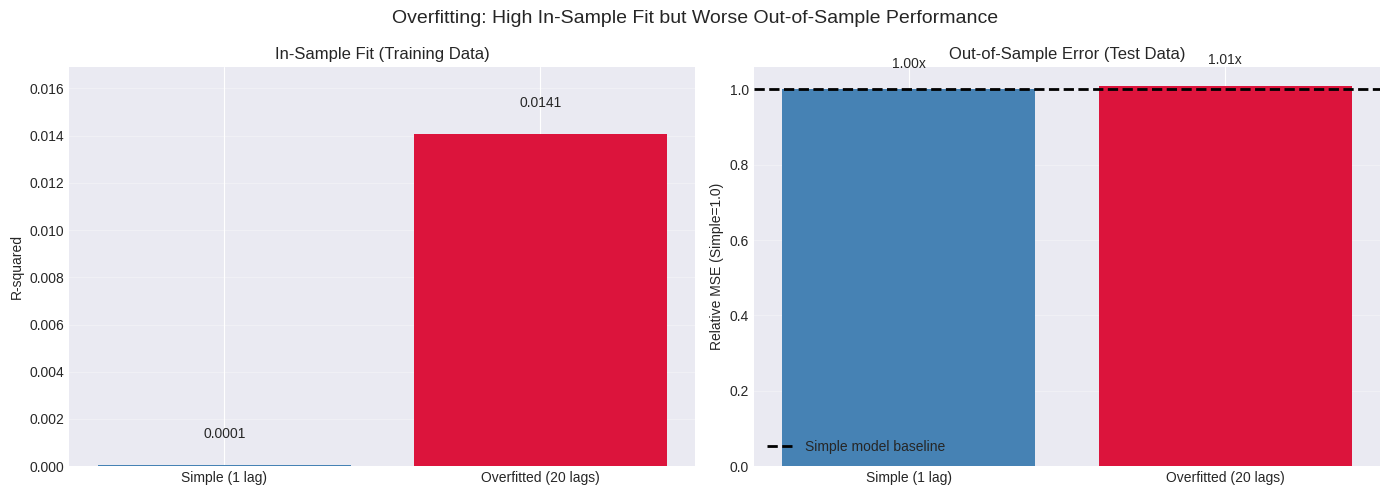

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Simple (1 lag)', 'Overfitted (20 lags)']
in_sample_r2 = [model_simple.rsquared, model_overfit.rsquared]
out_of_sample_mse = [mse_simple, mse_overfit]

# Normalize MSE for comparison
out_of_sample_mse_norm = [m / mse_simple for m in out_of_sample_mse]

# In-sample R²
bars1 = axes[0].bar(models, in_sample_r2, color=['steelblue', 'crimson'])
axes[0].set_ylabel('R-squared')
axes[0].set_title('In-Sample Fit (Training Data)', fontsize=12)
axes[0].set_ylim([0, max(in_sample_r2) * 1.2])
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars1, in_sample_r2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom')

# Out-of-sample MSE
bars2 = axes[1].bar(models, out_of_sample_mse_norm, color=['steelblue', 'crimson'])
axes[1].set_ylabel('Relative MSE (Simple=1.0)')
axes[1].set_title('Out-of-Sample Error (Test Data)', fontsize=12)
axes[1].axhline(y=1, color='black', linestyle='--', linewidth=2, label='Simple model baseline')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars2, out_of_sample_mse_norm):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}x', ha='center', va='bottom')

plt.suptitle('Overfitting: High In-Sample Fit but Worse Out-of-Sample Performance', fontsize=14)
plt.tight_layout()
plt.show()

# CHALLENGE 4: MULTICOLLINEARITY

DEFINITION

VIF_k = 1 / (1 - R²_k) where R²_k is from regressing X_k on other X's
VIF > 5 = problematic, VIF > 10 = severe multicollinearity


DESCRIPTION

Highly correlated predictors (e.g., multiple moving averages) inflate
standard errors and make coefficient estimates unstable.


NUMERICAL EXAMPLE

Features: Lag_1, Lag_2, SMA_5, SMA_10, RV_20
Observations: 1990





In [104]:
# Correlation matrix
feature_cols = ['Lag_1', 'Lag_2', 'SMA_5', 'SMA_10', 'RV_20']
corr_matrix = df_multi[feature_cols].corr()
print("\n【CORRELATION MATRIX】")
print(corr_matrix.round(3))

# Calculate VIF
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

X_vif = df_multi[feature_cols]
vif_result = calculate_vif(X_vif)
print("\n【VIF VALUES】")
print(vif_result.to_string(index=False))


【CORRELATION MATRIX】
        Lag_1  Lag_2  SMA_5  SMA_10  RV_20
Lag_1   1.000 -0.072  0.403   0.268 -0.004
Lag_2  -0.072  1.000  0.426   0.305 -0.018
SMA_5   0.403  0.426  1.000   0.691 -0.037
SMA_10  0.268  0.305  0.691   1.000 -0.114
RV_20  -0.004 -0.018 -0.037  -0.114  1.000

【VIF VALUES】
Variable      VIF
   Lag_1 1.312533
   Lag_2 1.342479
   SMA_5 2.556971
  SMA_10 1.964725
   RV_20 1.018216


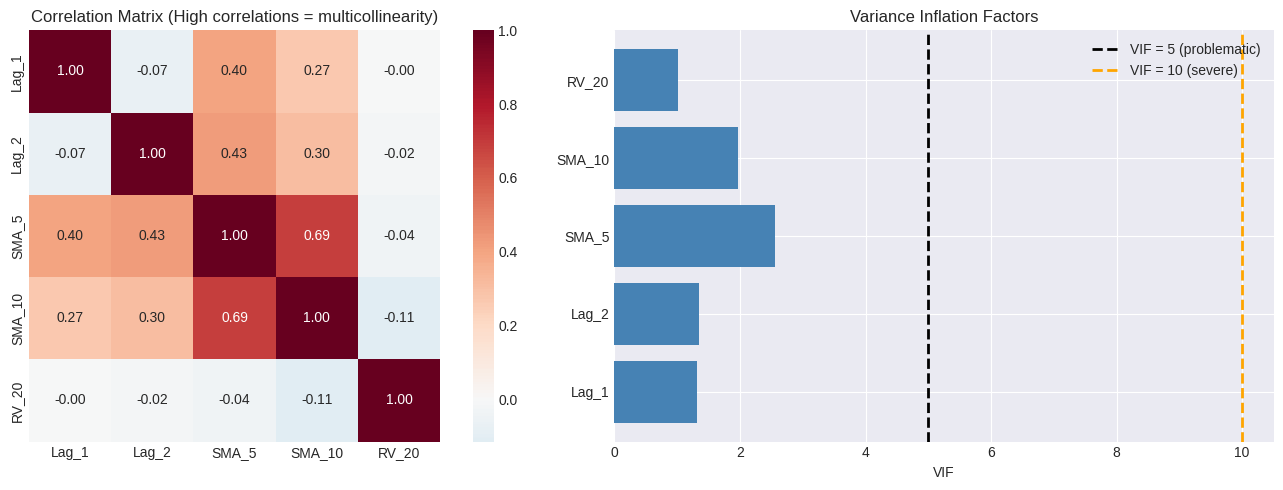

In [105]:
# Diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=axes[0], fmt='.2f', square=True)
axes[0].set_title('Correlation Matrix (High correlations = multicollinearity)', fontsize=12)

colors = ['steelblue' if v < 5 else 'crimson' for v in vif_result['VIF']]
axes[1].barh(vif_result['Variable'], vif_result['VIF'], color=colors)
axes[1].axvline(x=5, color='black', linestyle='--', linewidth=2, label='VIF = 5 (problematic)')
axes[1].axvline(x=10, color='orange', linestyle='--', linewidth=2, label='VIF = 10 (severe)')
axes[1].set_xlabel('VIF')
axes[1].set_title('Variance Inflation Factors', fontsize=12)
axes[1].legend()
plt.tight_layout()
plt.show()

# DIAGNOSIS
How to recognize multicollinearity:


-Correlation matrix: Look for |r| > 0.7 between predictors

-VIF > 5 (problematic) or VIF > 10 (severe)

-Coefficient instability: Small data changes cause large coefficient changes

【COEFFICIENT INSTABILITY】Tiny data change (1% noise):

Variable  Original  Noise Added  Change

   const   -0.0092      -0.0095  0.0003

   Lag_1   -0.2913      -0.2912  0.0001

   SMA_5    1.2332       1.2280  0.0052

  SMA_10    0.1492       0.1566  0.0075

⚠️ SMA_5 and SMA_10 change dramatically → multicollinearity!




# Damage
-When multicollinearity is not addressed, it can create major problems in financial modeling and analysis:


-Regression coefficients become unreliable, making it difficult to determine the actual variables driving risk and returns


-Hedging ratios may become highly unstable and change drastically when additional data is introduced


-Standard errors increase, which can lead to misleading statistical inferences and incorrect hypothesis testing results


-The estimated coefficients may display incorrect signs, resulting in false interpretations of variable relationships


-As a result, the overall reliability, accuracy, and interpretability of the model are weakened.


**Directions**

-Several techniques can be applied to minimize or eliminate multicollinearity:


-Use Principal Component Analysis (PCA) to transform correlated variables into independent components


-Apply Ridge Regression (L2 regularization) to reduce the impact of highly correlated predictors by shrinking coefficient estimates


-Remove unnecessary or redundant variables from the model, such as retaining SMA_5 while excluding SMA_10


-Implement Partial Least Squares (PLS) when the primary objective is prediction accuracy


-Increase the sample size whenever possible to improve the stability of parameter estimates


Best Practice
Variance Inflation Factor (VIF) analysis should always be performed before interpreting regression coefficients in order to detect and manage multicollinearity effectively.




# References
MLA References

Brooks, Chris. Introductory Econometrics for Finance. 4th ed., Cambridge University Press, 2019.

Gujarati, Damodar N., and Dawn C. Porter. Basic Econometrics. 5th ed., McGraw-Hill Education, 2009.

James, Gareth, et al. An Introduction to Statistical Learning. Springer, 2021.

Tsay, Ruey S. Analysis of Financial Time Series. 3rd ed., Wiley, 2010.

Wooldridge, Jeffrey M. Introductory Econometrics: A Modern Approach. 7th ed., Cengage Learning, 2020.